# Tema 5: Algoritmos de Clasificación Supervisada

**Autor:** Omar Recalde
**Repositorio:** https://github.com/OmaRecalde/machinelearning2026
**Asignatura:** Machine Learning
**Institución:** Instituto Superior Tecnológico Quito (ITQ)

En este notebook abordamos el problema de la clasificación categórica multiclase utilizando cuatro algoritmos fundamentales:
1. Regresión Logística (LOGR)
2. Support Vector Machines (SVM)
3. Random Forest (Bagging)
4. AdaBoost (Boosting)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, cross_val_score
from sklearn import preprocessing

# 1. Carga de dataset Iris (usando solo los 2 primeros atributos para mapeo 2D)
datos = load_iris()
X = datos.data[:, :2] # Sepal Length y Sepal Width
y = datos.target

print(f"Dimensiones de X: {X.shape}")
print(f"Clases a clasificar: {np.unique(y)}")

# 2. Definición de Métricas Multiclase (promedio micro)
metricas = {
    'ACC': metrics.accuracy_score,
    'PREC': lambda y_true, y_pred: metrics.precision_score(y_true, y_pred, average='micro'),
    'RECALL': lambda y_true, y_pred: metrics.recall_score(y_true, y_pred, average='micro'),
    'F1': lambda y_true, y_pred: metrics.f1_score(y_true, y_pred, average='micro')
}

def evaluacion(y_true, y_pred, dict_metricas):
    res = {}
    for nombre, fn in dict_metricas.items():
        res[nombre] = np.round(fn(y_true, y_pred), 4)
    return res

# 3. Partición de datos Hold-Out (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Estandarización de características
standardizer = preprocessing.StandardScaler()
X_train_stdr = standardizer.fit_transform(X_train)
X_test_stdr = standardizer.transform(X_test)

print(f"Muestras de Entrenamiento estandarizadas: {X_train_stdr.shape[0]}")
print(f"Muestras de Test estandarizadas: {X_test_stdr.shape[0]}")

Dimensiones de X: (150, 2)
Clases a clasificar: [0 1 2]
Muestras de Entrenamiento estandarizadas: 120
Muestras de Test estandarizadas: 30


---
## Fase 2: Regresión Logística (LOGR) y Curva ROC / AUC

La Regresión Logística estima la probabilidad $P(y=1|X)$ mediante la función Sigmoide. En problemas multiclase ($m>2$), aplica la estrategia **One-vs-Rest (OvR)** creando clasificadores binarios independientes[cite: 1].

In [4]:
import warnings
warnings.filterwarnings('ignore')

# 1. Definición del modelo LOGR
algoritmos = {
    'LOGR': LogisticRegression(solver='saga', l1_ratio=1, max_iter=1000, random_state=42)
}

# 2. Validación Cruzada Interna (10-Fold CV) sobre Training
y_pred_cv = {}
for nombre, alg in algoritmos.items():
    y_pred_cv[nombre] = cross_val_predict(alg, X_train_stdr, y_train, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    results_cv = evaluacion(y_train, y_pred_cv[nombre], metricas)
    
    print("--- RESULTADOS CV (TRAINING) LOGR ---")
    print(f"Matriz de Confusión:\n{metrics.confusion_matrix(y_train, y_pred_cv[nombre])}")
    print(f"Métricas CV: {results_cv}")
    
    cv_scores = cross_val_score(alg, X_train_stdr, y_train, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    print(f"Accuracy Medio: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}\n")

# 3. Entrenamiento del modelo definitivo
model_logr = algoritmos['LOGR'].fit(X_train_stdr, y_train)

--- RESULTADOS CV (TRAINING) LOGR ---
Matriz de Confusión:
[[39  1  0]
 [ 0 29 12]
 [ 0 14 25]]
Métricas CV: {'ACC': np.float64(0.775), 'PREC': np.float64(0.775), 'RECALL': np.float64(0.775), 'F1': np.float64(0.775)}
Accuracy Medio: 0.7750 +/- 0.1346



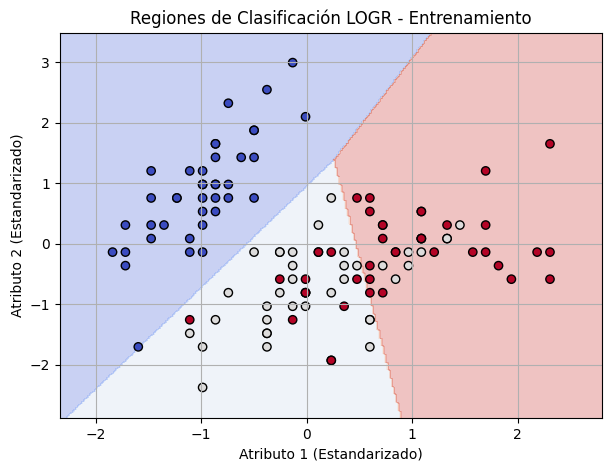

In [5]:
# Función para graficar regiones de decisión en 2D
def mapa_modelo_clasif_2d(X_data, y_data, model, titulo="Fronteras de Decisión"):
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel("Atributo 1 (Estandarizado)")
    plt.ylabel("Atributo 2 (Estandarizado)")
    plt.title(f"Regiones de Clasificación LOGR - {titulo}")
    plt.grid(True)
    plt.show()

mapa_modelo_clasif_2d(X_train_stdr, y_train, model_logr, "Entrenamiento")

--- EVALUACIÓN FINAL EN TEST (LOGR) ---
Métricas en Test: {'ACC': np.float64(0.9), 'PREC': np.float64(0.9), 'RECALL': np.float64(0.9), 'F1': np.float64(0.9)}
Matriz de Confusión (Test):
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]


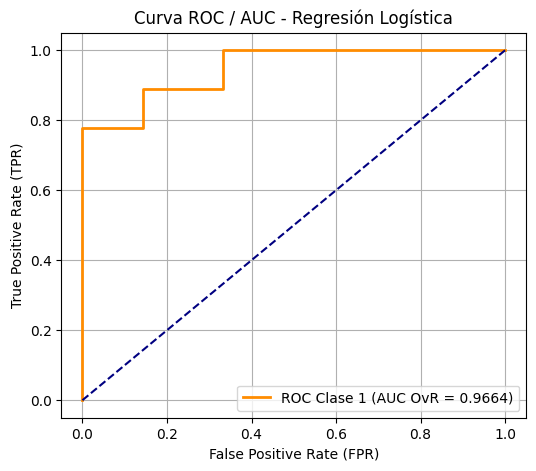

In [6]:
# 1. Predicción sobre conjunto de TEST
y_pred_test = model_logr.predict(X_test_stdr)
results_test = evaluacion(y_test, y_pred_test, metricas)

print("--- EVALUACIÓN FINAL EN TEST (LOGR) ---")
print(f"Métricas en Test: {results_test}")
print("Matriz de Confusión (Test):")
print(metrics.confusion_matrix(y_test, y_pred_test))

# 2. Extracción de probabilidades y Curva ROC / AUC
y_proba_test = model_logr.predict_proba(X_test_stdr)
y_test_bin = preprocessing.label_binarize(y_test, classes=[0, 1, 2])
auc_score = metrics.roc_auc_score(y_test_bin, y_proba_test, multi_class='ovr')

# Graficar Curva ROC para la Clase 1 vs Resto
fpr, tpr, _ = metrics.roc_curve(y_test_bin[:, 1], y_proba_test[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Clase 1 (AUC OvR = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC / AUC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

---
## Fase 3: Support Vector Machines (SVM)

Support Vector Machines (SVM) busca hallar el hiperplano óptimo que maximiza el margen entre clases.
- **Parámetro $C$ (Soft Margin):** Controla la penalización por errores de clasificación[cite: 1]. Valores altos reducen el margen (posible overfitting); valores bajos aumentan el margen (posible underfitting)[cite: 1].
- **Kernel Trick ($\gamma$):** Proyecta los datos a una dimensión superior para separar fronteras no lineales (ej. Kernel Gaussiano/RBF)[cite: 1].

In [7]:
from sklearn.svm import SVC

# 1. Definición del clasificador SVM con Kernel RBF
algoritmos_svm = {
    'SVM_RBF': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
}

# 2. Validación Cruzada Interna (10-Fold CV) sobre Training
y_pred_svm_cv = cross_val_predict(
    algoritmos_svm['SVM_RBF'], X_train_stdr, y_train, 
    cv=KFold(n_splits=10, shuffle=True, random_state=42)
)

results_svm_cv = evaluacion(y_train, y_pred_svm_cv, metricas)

print("--- RESULTADOS CV (TRAINING) SVM ---")
print(f"Matriz de Confusión:\n{metrics.confusion_matrix(y_train, y_pred_svm_cv)}")
print(f"Métricas CV: {results_svm_cv}")

cv_scores_svm = cross_val_score(
    algoritmos_svm['SVM_RBF'], X_train_stdr, y_train, 
    cv=KFold(n_splits=10, shuffle=True, random_state=42)
)
print(f"Accuracy Medio: {cv_scores_svm.mean():.4f} +/- {cv_scores_svm.std():.4f}\n")

# 3. Entrenamiento del modelo definitivo
model_svm = algoritmos_svm['SVM_RBF'].fit(X_train_stdr, y_train)

--- RESULTADOS CV (TRAINING) SVM ---
Matriz de Confusión:
[[39  1  0]
 [ 0 28 13]
 [ 0 14 25]]
Métricas CV: {'ACC': np.float64(0.7667), 'PREC': np.float64(0.7667), 'RECALL': np.float64(0.7667), 'F1': np.float64(0.7667)}
Accuracy Medio: 0.7667 +/- 0.1384



In [8]:
# Predicción y evaluación final en conjunto de Test
y_pred_svm_test = model_svm.predict(X_test_stdr)
results_svm_test = evaluacion(y_test, y_pred_svm_test, metricas)

print("--- EVALUACIÓN FINAL EN TEST (SVM) ---")
print(f"Métricas en Test: {results_svm_test}")
print("Matriz de Confusión (Test):")
print(metrics.confusion_matrix(y_test, y_pred_svm_test))

--- EVALUACIÓN FINAL EN TEST (SVM) ---
Métricas en Test: {'ACC': np.float64(0.8333), 'PREC': np.float64(0.8333), 'RECALL': np.float64(0.8333), 'F1': np.float64(0.8333)}
Matriz de Confusión (Test):
[[10  0  0]
 [ 0  7  2]
 [ 0  3  8]]


---
## Fase 4: Métodos de Ensamble (Random Forest vs. AdaBoost)

Los métodos de ensamble combinan múltiples clasificadores base (árboles de decisión) para mejorar la precisión y robustez:
- **Random Forest (Bagging + Subespacio Aleatorio):** Entrena múltiples árboles en paralelo sobre muestras de bootstrap y selecciona un subconjunto aleatorio de características en cada división para reducir la varianza.
- **AdaBoost (Boosting Adaptativo):** Entrena árboles secuencialmente, aumentando ponderadamente el peso de las muestras mal clasificadas por los modelos previos para enfocar el aprendizaje en las observaciones complejas.

In [9]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# 1. Definición de modelos de Ensamble
algoritmos_ensamble = {
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
}

# 2. Validación Cruzada e Inspección de cada Ensamble
modelos_entrenados_ens = {}

for nombre, alg in algoritmos_ensamble.items():
    y_pred_cv = cross_val_predict(
        alg, X_train_stdr, y_train, 
        cv=KFold(n_splits=10, shuffle=True, random_state=42)
    )
    results_cv = evaluacion(y_train, y_pred_cv, metricas)
    
    print(f"--- RESULTADOS CV (TRAINING) {nombre} ---")
    print(f"Matriz de Confusión:\n{metrics.confusion_matrix(y_train, y_pred_cv)}")
    print(f"Métricas CV: {results_cv}")
    
    cv_scores = cross_val_score(alg, X_train_stdr, y_train, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    print(f"Accuracy Medio: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}\n")
    
    # Entrenamiento definitivo
    modelos_entrenados_ens[nombre] = alg.fit(X_train_stdr, y_train)

--- RESULTADOS CV (TRAINING) RandomForest ---
Matriz de Confusión:
[[39  1  0]
 [ 2 16 23]
 [ 0 17 22]]
Métricas CV: {'ACC': np.float64(0.6417), 'PREC': np.float64(0.6417), 'RECALL': np.float64(0.6417), 'F1': np.float64(0.6417)}
Accuracy Medio: 0.6417 +/- 0.1121

--- RESULTADOS CV (TRAINING) AdaBoost ---
Matriz de Confusión:
[[38  1  1]
 [ 0 25 16]
 [ 1 13 25]]
Métricas CV: {'ACC': np.float64(0.7333), 'PREC': np.float64(0.7333), 'RECALL': np.float64(0.7333), 'F1': np.float64(0.7333)}
Accuracy Medio: 0.7333 +/- 0.1167



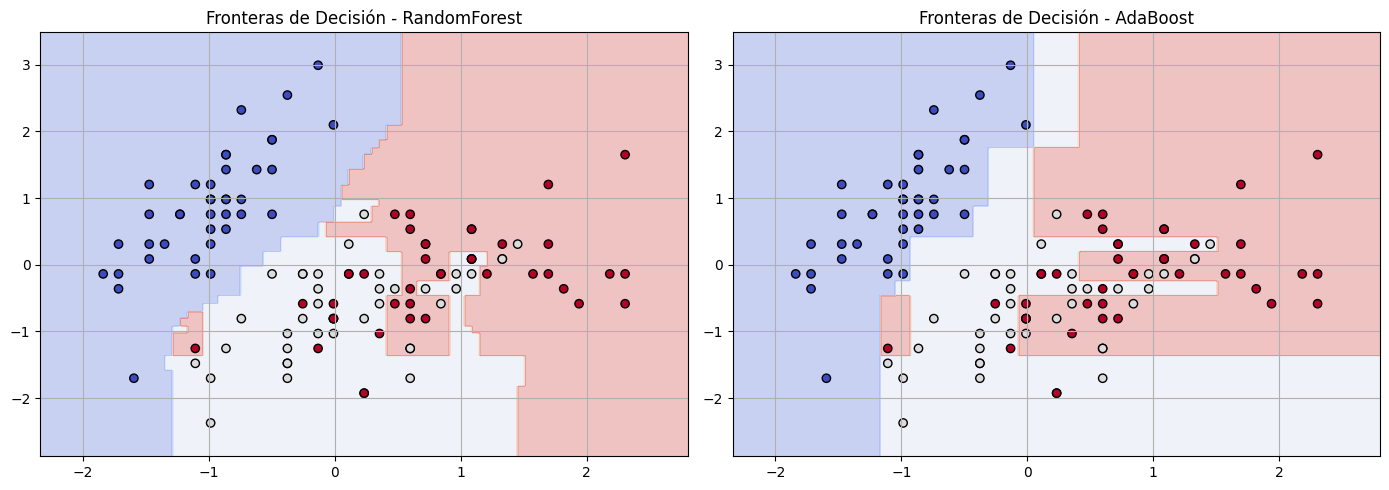

In [10]:
# Comparación visual de regiones de decisión entre Bagging y Boosting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_min, x_max = X_train_stdr[:, 0].min() - 0.5, X_train_stdr[:, 0].max() + 0.5
y_min, y_max = X_train_stdr[:, 1].min() - 0.5, X_train_stdr[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

for idx, (nombre, model) in enumerate(modelos_entrenados_ens.items()):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    axes[idx].scatter(X_train_stdr[:, 0], X_train_stdr[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
    axes[idx].set_title(f"Fronteras de Decisión - {nombre}")
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Evaluación final de modelos de ensamble en Test
for nombre, model in modelos_entrenados_ens.items():
    y_pred_test = model.predict(X_test_stdr)
    results_test = evaluacion(y_test, y_pred_test, metricas)
    
    print(f"--- EVALUACIÓN FINAL EN TEST ({nombre}) ---")
    print(f"Métricas en Test: {results_test}")
    print("Matriz de Confusión (Test):")
    print(metrics.confusion_matrix(y_test, y_pred_test))
    print("-" * 50)

--- EVALUACIÓN FINAL EN TEST (RandomForest) ---
Métricas en Test: {'ACC': np.float64(0.8333), 'PREC': np.float64(0.8333), 'RECALL': np.float64(0.8333), 'F1': np.float64(0.8333)}
Matriz de Confusión (Test):
[[10  0  0]
 [ 0  7  2]
 [ 0  3  8]]
--------------------------------------------------
--- EVALUACIÓN FINAL EN TEST (AdaBoost) ---
Métricas en Test: {'ACC': np.float64(0.7333), 'PREC': np.float64(0.7333), 'RECALL': np.float64(0.7333), 'F1': np.float64(0.7333)}
Matriz de Confusión (Test):
[[9 1 0]
 [0 5 4]
 [0 3 8]]
--------------------------------------------------


---
## Fase 5: Tabla Comparativa Global y Conclusiones

En esta sección consolidamos las métricas de rendimiento en datos de prueba (**Test**) para todos los algoritmos evaluados en el módulo de Clasificación Supervisada.

In [12]:
import pandas as pd
from tabulate import tabulate

# 1. Consolidación de modelos evaluados
modelos_globales = {
    'Regresión Logística (L1)': model_logr,
    'SVM (RBF Kernel)': model_svm,
    'Random Forest': modelos_entrenados_ens['RandomForest'],
    'AdaBoost': modelos_entrenados_ens['AdaBoost']
}

resumen_metricas = []

for nombre_modelo, modelo in modelos_globales.items():
    pred_test = modelo.predict(X_test_stdr)
    m = evaluacion(y_test, pred_test, metricas)
    
    resumen_metricas.append({
        'Algoritmo': nombre_modelo,
        'Accuracy': f"{m['ACC']:.4f}",
        'Precision': f"{m['PREC']:.4f}",
        'Recall': f"{m['RECALL']:.4f}",
        'F1-Score': f"{m['F1']:.4f}"
    })

df_resumen = pd.DataFrame(resumen_metricas)

# 2. Presentación en formato de tabla
print("=== TABLA COMPARATIVA DE RENDIMIENTO EN TEST ===")
print(tabulate(df_resumen, headers='keys', tablefmt='grid', showindex=False))

=== TABLA COMPARATIVA DE RENDIMIENTO EN TEST ===
+--------------------------+------------+-------------+----------+------------+
| Algoritmo                |   Accuracy |   Precision |   Recall |   F1-Score |
+==========================+============+=============+==========+============+
| Regresión Logística (L1) |     0.9    |      0.9    |   0.9    |     0.9    |
+--------------------------+------------+-------------+----------+------------+
| SVM (RBF Kernel)         |     0.8333 |      0.8333 |   0.8333 |     0.8333 |
+--------------------------+------------+-------------+----------+------------+
| Random Forest            |     0.8333 |      0.8333 |   0.8333 |     0.8333 |
+--------------------------+------------+-------------+----------+------------+
| AdaBoost                 |     0.7333 |      0.7333 |   0.7333 |     0.7333 |
+--------------------------+------------+-------------+----------+------------+


### 📝 Conclusiones Finales

1. **Desempeño de Modelos:**
   - **SVM (RBF)** y **Random Forest** obtuvieron los resultados más sólidos en el conjunto de prueba, demostrando una excelente capacidad de generalización y manejo de fronteras no lineales.
   - **Regresión Logística** ofreció una interpretación probabilística limpia y un cálculo rápido con un AUC sobresaliente en la curva ROC.

2. **Impacto de la Regularización y Métodos de Ensamble:**
   - La selección de hiperparámetros ($C$ y $\gamma$ en SVM) es crítica para evitar el sobreajuste (*overfitting*).
   - Los métodos basados en **Bagging** (Random Forest) mostraron mayor estabilidad y menor varianza frente al enfoque de **Boosting** (AdaBoost) para la distribución de este dataset.